# Rising Bubble PINN: обучение по этапам

Ноутбук запускает тот же PyTorch pipeline, что и `train_rising_bubble.py`, но по отдельным этапам. После каждой ячейки этапа можно смотреть loss, checkpoints и графики истории.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch

cwd = Path.cwd().resolve()
PROJECT_DIR = cwd if (cwd / "pinn").exists() else cwd / "diploma"
ROOT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

from pinn.config import preset_config
from pinn.train import TrainingRun, resolve_device

print("project:", PROJECT_DIR)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

project: /Users/erklyavlin/repos/diploma/diploma
torch: 2.11.0
cuda available: False


## 1. Конфигурация

`smoke` нужен для быстрой проверки. Для рабочего запуска поменяй `preset_name` на `default`; для максимально близкого к статье запуска - на `paper`.

In [2]:
preset_name = "paper"  # smoke | default | paper
cfg = preset_config(preset_name)

cfg.data_path = ROOT_DIR / "diploma" / "cfd_data" / "rising_bubble.h5"
# cfg.data_path = ROOT_DIR / "diploma" / "exp" / "train"
cfg.output_dir = PROJECT_DIR / "checkpoints"
cfg.device = "auto"  # auto | cpu | cuda | cuda:0
cfg.dtype = "float32"

# Примеры точечной настройки без CLI:
# cfg.epochs = (500, 500, 500)
# cfg.learning_rates = (1e-4, 5e-5, 1e-5)
# cfg.hidden_layers = (256,) * 6
# cfg.batch_size = 4096  # ручной total batch size
# cfg.batch_size = None; cfg.num_batches = 20  # как у авторов: ceil(total_points / 20)

assert cfg.data_path.exists(), f"Не найден файл данных: {cfg.data_path}"
assert len(cfg.epochs) == len(cfg.learning_rates)

cfg.to_dict()

{'data_path': '/Users/erklyavlin/repos/diploma/diploma/cfd_data/rising_bubble.h5',
 'output_dir': '/Users/erklyavlin/repos/diploma/diploma/checkpoints',
 'hidden_layers': (350, 350, 350, 350, 350, 350, 350, 350),
 'activation': 'tanh',
 'points': {'alpha': (500, 400),
  'pde': (400, 2000, 3000),
  'north': (20, 20),
  'south': (20, 20),
  'east': (20, 20),
  'west': (20, 20)},
 'physics': {'mu': (1.0, 10.0),
  'rho': (100.0, 1000.0),
  'sigma': 24.5,
  'g': -0.98,
  'u_ref': 1.0,
  'l_ref': 0.25,
  'p_ref_rho': 1000.0},
 'loss_weights_pde': (1.0, 10.0, 10.0, 1.0),
 'epochs': (5000, 5000, 5000, 5000, 5000),
 'learning_rates': (0.0001, 5e-05, 1e-05, 5e-06, 1e-06),
 'batch_size': None,
 'num_batches': 20,
 'checkpoint_interval': 100,
 'seed': 1234,
 'device': 'auto',
 'dtype': 'float32',
 'num_workers': 0}

## 2. Создание training run

Эта ячейка загружает и сэмплирует данные, создает модель, optimizer и папку запуска в `diploma/checkpoints/<timestamp>`.

In [3]:
run = TrainingRun(cfg)
run.run_dir

Loading and sampling training data from /Users/erklyavlin/repos/diploma/diploma/cfd_data/rising_bubble.h5
Training point counts: {'alpha': 26100, 'pde': 158200, 'north': 400, 'east_west': 400, 'nsew': 840}
Device: cpu, dtype: torch.float32, total batch size: 9297, batches/epoch: 20, batch sizes: {'alpha': 1305, 'pde': 7910, 'north': 20, 'east_west': 20, 'nsew': 42}


PosixPath('/Users/erklyavlin/repos/diploma/diploma/checkpoints/20260519_155923')

In [4]:
def history_frame(run):
    if not run.history:
        return pd.DataFrame()
    return pd.DataFrame(run.history)


def plot_losses(run, keys=("total", "alpha", "continuity", "momentum_x", "momentum_y")):
    df = history_frame(run)
    if df.empty:
        print("История пока пустая.")
        return df
    available = [key for key in keys if key in df.columns]
    ax = df.plot(x="epoch", y=available, logy=True, figsize=(10, 5), grid=True)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title("Training losses")
    plt.show()
    return df.tail()


def checkpoint_files(run):
    return sorted(path.name for path in run.run_dir.glob("*.pt"))

## 3. Этап 1

In [ ]:
stage = 1
run.train_stage(stage=stage)
plot_losses(run)
checkpoint_files(run)

stage 1 lr=0.0001:   0%|          | 0/5000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
stage 1 lr=0.0001:   0%|          | 13/5000 [00:10<1:01:28,  1.35it/s, alpha=2.13e-01, pde_u=1.01e-04, total=2.248e-01]

## 4. Этап 2

Запускай эту ячейку, если в конфигурации есть второй этап.

stage 2 lr=5e-05: 100%|██████████| 5000/5000 [1:00:47<00:00,  1.37it/s, alpha=5.54e-03, pde_u=2.41e-04, total=1.157e-02]


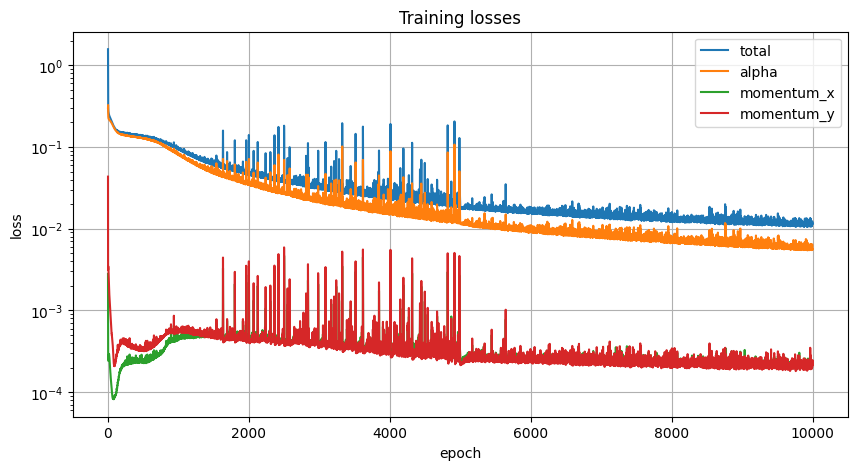

['best.pt',
 'epoch_000100.pt',
 'epoch_000200.pt',
 'epoch_000300.pt',
 'epoch_000400.pt',
 'epoch_000500.pt',
 'epoch_000600.pt',
 'epoch_000700.pt',
 'epoch_000800.pt',
 'epoch_000900.pt',
 'epoch_001000.pt',
 'epoch_001100.pt',
 'epoch_001200.pt',
 'epoch_001300.pt',
 'epoch_001400.pt',
 'epoch_001500.pt',
 'epoch_001600.pt',
 'epoch_001700.pt',
 'epoch_001800.pt',
 'epoch_001900.pt',
 'epoch_002000.pt',
 'epoch_002100.pt',
 'epoch_002200.pt',
 'epoch_002300.pt',
 'epoch_002400.pt',
 'epoch_002500.pt',
 'epoch_002600.pt',
 'epoch_002700.pt',
 'epoch_002800.pt',
 'epoch_002900.pt',
 'epoch_003000.pt',
 'epoch_003100.pt',
 'epoch_003200.pt',
 'epoch_003300.pt',
 'epoch_003400.pt',
 'epoch_003500.pt',
 'epoch_003600.pt',
 'epoch_003700.pt',
 'epoch_003800.pt',
 'epoch_003900.pt',
 'epoch_004000.pt',
 'epoch_004100.pt',
 'epoch_004200.pt',
 'epoch_004300.pt',
 'epoch_004400.pt',
 'epoch_004500.pt',
 'epoch_004600.pt',
 'epoch_004700.pt',
 'epoch_004800.pt',
 'epoch_004900.pt',
 'epoch_

In [6]:
stage = 2
if stage <= len(cfg.epochs):
    run.train_stage(stage=stage)
plot_losses(run)
checkpoint_files(run)

## 5. Этап 3

Запускай эту ячейку, если в конфигурации есть третий этап.

In [ ]:
stage = 3
if stage <= len(cfg.epochs):
    run.train_stage(stage=stage)
plot_losses(run)
checkpoint_files(run)

stage 3 lr=1e-05:  64%|██████▍   | 3194/5000 [38:46<21:41,  1.39it/s, alpha=4.66e-03, pde_u=1.87e-04, total=9.465e-03] 

## 6. Дополнительный этап

Можно продолжить обучение с другой скоростью обучения, не меняя checkpoint вручную.

In [ ]:
# run.train_stage(epochs=200, lr=5e-6, stage=run.current_stage + 1)
# plot_losses(run)
# checkpoint_files(run)

## 7. История и checkpoints

In [ ]:
history_path = run.run_dir / "history.json"
config_path = run.run_dir / "config.json"

print("run_dir:", run.run_dir)
print("best:", run.run_dir / "best.pt")
print("last:", run.run_dir / "last.pt")
print("history:", history_path)

history_frame(run).tail(10)

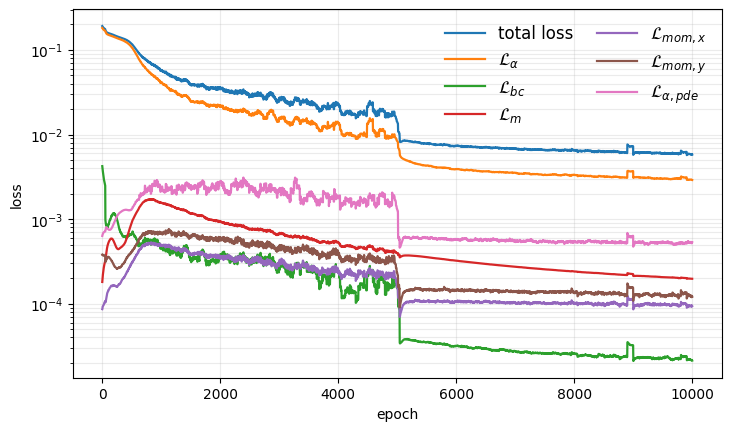

history: /Users/erklyavlin/repos/diploma/diploma/checkpoints_param_paper_2stage/hard/history.json
saved: /Users/erklyavlin/repos/diploma/figures/training_history.png
\includegraphics[width=0.85\textwidth]{figures/training_history.png}


In [9]:
# Рисунок для main.tex: история обучения.
# Можно указать путь до best.pt/last.pt, директории run или сразу до history.json.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DIPLOMA_HISTORY_SOURCE = PROJECT_DIR / "checkpoints_param_paper_2stage" / "hard" / "best.pt"
DIPLOMA_HISTORY_OUTPUT_DIR = ROOT_DIR / "figures"
DIPLOMA_HISTORY_OUTPUT_PATH = DIPLOMA_HISTORY_OUTPUT_DIR / "training_history.png"


def resolve_history_path(source):
    source = Path(source)

    if source.name == "history.json":
        return source

    if source.suffix == ".pt":
        return source.parent / "history.json"

    if source.is_dir():
        return source / "history.json"

    raise FileNotFoundError(f"Не удалось определить history.json из пути: {source}")


history_path = resolve_history_path(DIPLOMA_HISTORY_SOURCE)
assert history_path.exists(), f"Не найден history.json: {history_path}"

history_df = pd.read_json(history_path)

loss_columns = [
    "total",
    "alpha",
    "boundary",
    "mass",
    "momentum_x",
    "momentum_y",
    "alpha_pde",
]

loss_labels = {
    "total": "total loss",
    "alpha": r"$\mathcal{L}_\alpha$",
    "boundary": r"$\mathcal{L}_{bc}$",
    "mass": r"$\mathcal{L}_m$",
    "momentum_x": r"$\mathcal{L}_{mom,x}$",
    "momentum_y": r"$\mathcal{L}_{mom,y}$",
    "alpha_pde": r"$\mathcal{L}_{\alpha,pde}$",
}

available_columns = [
    column for column in loss_columns
    if column in history_df.columns
]

assert available_columns, f"В {history_path} не найдены loss-колонки: {loss_columns}"

smooth_window = 100

fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)

for column in available_columns:
    smoothed_loss = history_df[column].rolling(
        window=smooth_window,
        min_periods=1,
        center=True,
    ).mean()

    ax.plot(
        history_df["epoch"],
        smoothed_loss,
        label=loss_labels[column],
        linewidth=1.6,
    )

ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, which="both", alpha=0.25)
ax.legend(
    ncol=2,
    fontsize=12,
    frameon=False,
    handlelength=2.4,
    columnspacing=1.4,
    labelspacing=0.5,
)
DIPLOMA_HISTORY_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(DIPLOMA_HISTORY_OUTPUT_PATH, dpi=300, bbox_inches="tight")

plt.show()

relative_path = DIPLOMA_HISTORY_OUTPUT_PATH.relative_to(ROOT_DIR).as_posix()

print(f"history: {history_path}")
print(f"saved: {DIPLOMA_HISTORY_OUTPUT_PATH}")
print(f"\\includegraphics[width=0.85\\textwidth]{{{relative_path}}}")

## 8. Визуализация предсказаний

Сравнение полей CFD и PINN на регулярной сетке: истинное значение, предсказание и ошибка. Для ускорения можно увеличить `spatial_step`.

In [ ]:
from pinn.visualize import align_pressure_gauge, error_metrics, plot_centerline, plot_field_comparison, predict_cfd_grid

# Если ноутбук был открыт заново и переменной run нет, укажи checkpoint вручную:
# checkpoint_path = PROJECT_DIR / "checkpoints" / "20260504_101454" / "best.pt"
# checkpoint_path = run.run_dir / "best.pt"
# checkpoint_path = "D:/diploma_jupyter/diploma/checkpoints/20260504_110505" + "/best.pt"
# data_path = cfg.data_path

checkpoint_path = "/erklyavlin/diploma/diploma/checkpoints_param_paper_2stage/hard" + "/best.pt"
# checkpoint_path = "/erklyavlin/diploma/diploma/checkpoints_param_medium_2stage/light"+ "/best.pt"
data_path = "/erklyavlin/diploma/diploma/exp/test/rising_bubble_R030.h5"
# data_path = "/erklyavlin/diploma/diploma/exp/train/rising_bubble_R018.h5"
pred, true, coords = predict_cfd_grid(
    checkpoint_path=checkpoint_path,
    data_path=data_path,
    device=cfg.device,
    start=0,
    end=151,
    temporal_step=10,
    spatial_step=4,
)

pred_aligned = align_pressure_gauge(pred, true)

print("prediction shapes:", {name: value.shape for name, value in pred.items()})
error_metrics(pred_aligned, true)

prediction shapes: {'u': (16, 128, 64), 'v': (16, 128, 64), 'p': (16, 128, 64), 'alpha': (16, 128, 64)}


,field,rmse,mae,relative_rmse,pred_min,pred_max,true_min,true_max
0,u,0.020041,0.012757,0.299390,-2.824776e-01,0.282053,-0.348942,0.349515
1,v,0.030816,0.019837,0.203862,-5.544761e-01,0.426719,-0.667430,0.452339
2,p,0.071498,0.051459,0.012011,5.060561e+00,6.783664,4.983697,6.998086
3,alpha,0.037733,0.004697,0.100361,2.005401e-13,1.000000,0.000000,1.000000


In [ ]:
time_index = -1  # -1 = последний выбранный временной слой
fig = plot_field_comparison(
    pred,
    true,
    coords,
    time_index=time_index,
    fields=("alpha", "u", "v", "p"),
    save_path=run.run_dir / f"comparison_t{time_index}.png",
)

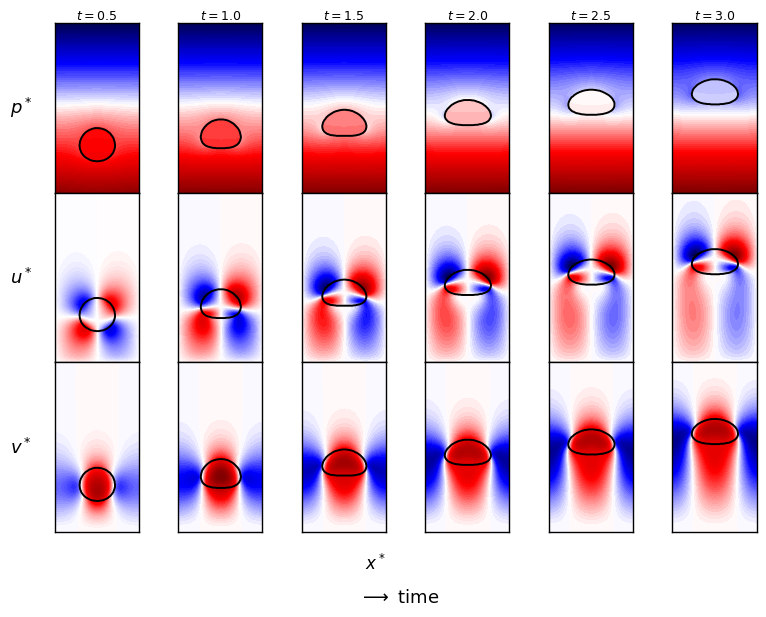

data: /Users/erklyavlin/repos/diploma/diploma/exp/test/rising_bubble_R020.h5
radius: R=0.2
requested times: (0.5, 1.0, 1.5, 2.0, 2.5, 3.0)
actual times: (0.5000148767500001, 1.0000297534999991, 1.5000446302499981, 2.0000595069999973, 2.5000743837499964, 3.0000892604999954)
saved: /Users/erklyavlin/repos/diploma/figures/r020_timeline_puv.png
\includegraphics[width=0.95\textwidth]{figures/r020_timeline_puv.png}


In [8]:
# Рисунок для main.tex: эволюция полей p*, u*, v* по времени для R=0.20.
# Можно указать путь до best.pt/last.pt, чтобы взять физические масштабы для безразмерных величин.
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

from pinn.config import PhysicsConfig
from pinn.data import radius_from_h5_path

DIPLOMA_TIMELINE_CHECKPOINT = PROJECT_DIR / "checkpoints_param_paper_2stage" / "hard" / "best.pt"
DIPLOMA_TIMELINE_DATA_PATH = PROJECT_DIR / "exp" / "test" / "rising_bubble_R020.h5"
DIPLOMA_TIMELINE_TIMES = (0.5, 1.0, 1.5, 2.0, 2.5, 3.0)
DIPLOMA_TIMELINE_SPATIAL_STEP = 4
DIPLOMA_TIMELINE_OUTPUT_DIR = ROOT_DIR / "figures"
DIPLOMA_TIMELINE_OUTPUT_PATH = DIPLOMA_TIMELINE_OUTPUT_DIR / "r020_timeline_puv.png"


def physics_from_checkpoint(checkpoint_path):
    checkpoint = torch.load(Path(checkpoint_path), map_location="cpu")
    return PhysicsConfig(**checkpoint["config"]["physics"])


def nearest_indices(values, targets):
    values = np.asarray(values)
    return [int(np.argmin(np.abs(values - target))) for target in targets]


physics = physics_from_checkpoint(DIPLOMA_TIMELINE_CHECKPOINT)
radius = radius_from_h5_path(DIPLOMA_TIMELINE_DATA_PATH)

with h5py.File(DIPLOMA_TIMELINE_DATA_PATH, "r") as data:
    x = np.asarray(data["X"])[::DIPLOMA_TIMELINE_SPATIAL_STEP] / physics.l_ref
    y = np.asarray(data["Y"])[::DIPLOMA_TIMELINE_SPATIAL_STEP] / physics.l_ref
    time_raw = np.asarray(data["time"])
    time_indices = nearest_indices(time_raw, DIPLOMA_TIMELINE_TIMES)
    actual_times = [float(time_raw[index]) for index in time_indices]

    levelset = np.asarray(data["levelset"])[time_indices, ::DIPLOMA_TIMELINE_SPATIAL_STEP, ::DIPLOMA_TIMELINE_SPATIAL_STEP]
    pressure = np.asarray(data["pressure"])[time_indices, ::DIPLOMA_TIMELINE_SPATIAL_STEP, ::DIPLOMA_TIMELINE_SPATIAL_STEP]
    velocity_x = np.asarray(data["velocityX"])[time_indices, ::DIPLOMA_TIMELINE_SPATIAL_STEP, ::DIPLOMA_TIMELINE_SPATIAL_STEP]
    velocity_y = np.asarray(data["velocityY"])[time_indices, ::DIPLOMA_TIMELINE_SPATIAL_STEP, ::DIPLOMA_TIMELINE_SPATIAL_STEP]

fields = {
    "p": np.transpose(pressure, (0, 2, 1)) / (physics.p_ref_rho * physics.u_ref**2),
    "u": np.transpose(velocity_x, (0, 2, 1)) / physics.u_ref,
    "v": np.transpose(velocity_y, (0, 2, 1)) / physics.u_ref,
}
levelset_yx = np.transpose(levelset, (0, 2, 1))

row_specs = [
    ("p", r"$p^*$", "seismic"),
    ("u", r"$u^*$", "seismic"),
    ("v", r"$v^*$", "seismic"),
]
limits = {}
for field_name, _, _ in row_specs:
    values = fields[field_name]
    if field_name == "p":
        limits[field_name] = (float(values.min()), float(values.max()))
    else:
        vmax = float(np.max(np.abs(values)))
        limits[field_name] = (-vmax, vmax)

nrows = len(row_specs)
ncols = len(time_indices)
fig, axes = plt.subplots(nrows, ncols, figsize=(1.35 * ncols, 2.15 * nrows), constrained_layout=False)
fig.subplots_adjust(left=0.08, right=0.995, bottom=0.12, top=0.91, wspace=0.0, hspace=0.0)

for row, (field_name, field_label, cmap) in enumerate(row_specs):
    vmin, vmax = limits[field_name]
    for col, time_index in enumerate(time_indices):
        ax = axes[row, col]
        ax.contourf(x, y, fields[field_name][col], levels=80, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.contour(x, y, levelset_yx[col], levels=[0.0], colors="black", linewidths=1.4)
        ax.set_aspect("equal")
        ax.set_xlim(float(x.min()), float(x.max()))
        ax.set_ylim(float(y.min()), float(y.max()))
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        if row == 0:
            ax.set_title(rf"$t={actual_times[col]:.1f}$", fontsize=9, pad=2)
        if col == 0:
            ax.set_ylabel(field_label, rotation=0, labelpad=24, fontsize=13, va="center")

        for spine in ax.spines.values():
            spine.set_linewidth(1.0)

fig.supxlabel(r"$x^*$", y=0.055, fontsize=12)
fig.text(0.53, 0.018, r"$\longrightarrow$ time", ha="center", va="center", fontsize=13)

DIPLOMA_TIMELINE_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(DIPLOMA_TIMELINE_OUTPUT_PATH, dpi=240, bbox_inches="tight")
plt.show()

relative_path = DIPLOMA_TIMELINE_OUTPUT_PATH.relative_to(ROOT_DIR).as_posix()
print(f"data: {DIPLOMA_TIMELINE_DATA_PATH}")
print(f"radius: R={radius:.3g}")
print(f"requested times: {DIPLOMA_TIMELINE_TIMES}")
print(f"actual times: {tuple(actual_times)}")
print(f"saved: {DIPLOMA_TIMELINE_OUTPUT_PATH}")
print(f"\\includegraphics[width=0.95\\textwidth]{{{relative_path}}}")


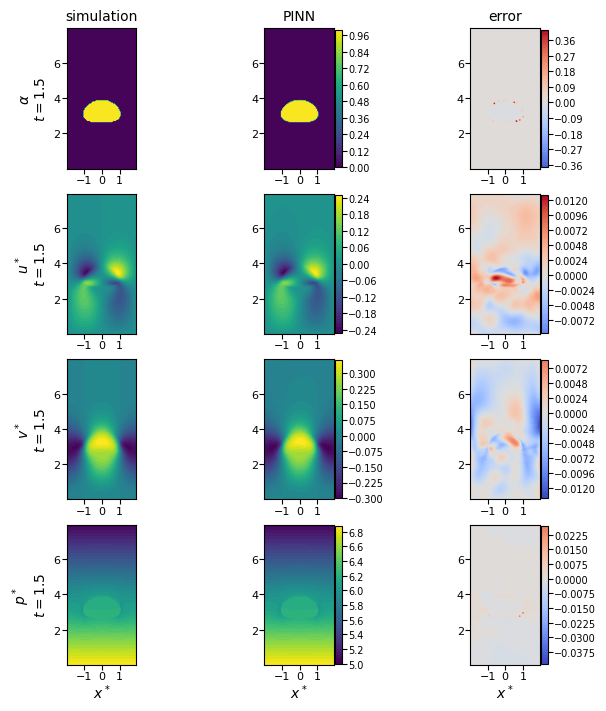

saved r020: /Users/erklyavlin/repos/diploma/figures/r020_comparison_t1p50004.png
actual times: [1.5000446302499981]


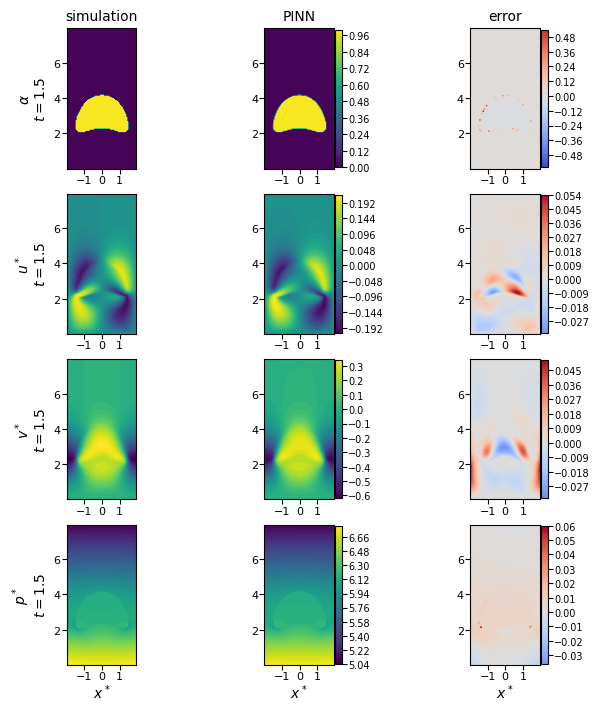

saved r030: /Users/erklyavlin/repos/diploma/figures/r030_comparison_t1p50004.png
actual times: [1.5000446302499981]

LaTeX includegraphics:
% requested times (1.5,), actual times (1.5000446302499981,)
\includegraphics[width=\textwidth]{figures/r020_comparison_t1p50004.png}
% requested times (1.5,), actual times (1.5000446302499981,)
\includegraphics[width=\textwidth]{figures/r030_comparison_t1p50004.png}


In [7]:
# Рисунки для main.tex: сравнение симуляции и PINN на R=0.20/R=0.30.
# Здесь можно вручную поменять checkpoint и HDF5-файлы с данными.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pinn.data import radius_from_h5_path
from pinn.visualize import predict_cfd_grid

DIPLOMA_FIGURE_CHECKPOINT = PROJECT_DIR / "checkpoints_param_paper_2stage" / "hard" / "best.pt"
DIPLOMA_FIGURE_DATA = {
    "r020": PROJECT_DIR / "exp" / "test" / "rising_bubble_R020.h5",
    "r030": PROJECT_DIR / "exp" / "test" / "rising_bubble_R030.h5",
}
DIPLOMA_FIGURE_TIMES = (1.5,)
DIPLOMA_FIGURE_OUTPUT_DIR = ROOT_DIR / "figures"
DIPLOMA_FIGURE_DEVICE = "auto"  # auto | cpu | cuda | cuda:0
DIPLOMA_FIGURE_START = 0
DIPLOMA_FIGURE_END = 151
DIPLOMA_FIGURE_TEMPORAL_STEP = 1  # 1 точнее выбирает t=1.5; увеличь для ускорения
DIPLOMA_FIGURE_SPATIAL_STEP = 4
DIPLOMA_FIGURE_BATCH_SIZE = 262_144
DIPLOMA_FIGURE_FIELDS = ("alpha", "u", "v", "p")
DIPLOMA_FIGURE_FIELD_LABELS = {
    "alpha": r"$\alpha$",
    "u": r"$u^*$",
    "v": r"$v^*$",
    "p": r"$p^*$",
}


def nearest_time_indices(time_values, requested_times):
    time_values = np.asarray(time_values)
    return [int(np.argmin(np.abs(time_values - requested_time))) for requested_time in requested_times]


def safe_time_tag(value):
    return f"{value:g}".replace("-", "m").replace(".", "p")


def align_pressure_at_time(pred_field, true_field):
    return pred_field + (true_field[-1, :].mean() - pred_field[-1, :].mean())


def plot_diploma_field_comparison(
    pred,
    true,
    coords,
    time_indices,
    fields=("alpha", "u", "v", "p"),
    radius_label="",
    save_path=None,
):
    x = coords["x"]
    y = coords["y"]
    time_raw = np.asarray(coords["time_raw"])
    nrows = len(fields) * len(time_indices)
    fig, axes = plt.subplots(nrows, 3, figsize=(6.9, 1.85 * nrows), constrained_layout=False)
    fig.subplots_adjust(left=0.08, right=0.97, bottom=0.07, top=0.93, wspace=0.015, hspace=0.18)
    if nrows == 1:
        axes = axes.reshape(1, 3)

    row = 0
    for time_index in time_indices:
        t_value = float(time_raw[time_index])
        for field in fields:
            pred_field = pred[field][time_index]
            true_field = true[field][time_index]
            if field == "p":
                pred_field = align_pressure_at_time(pred_field, true_field)

            err_field = pred_field - true_field
            vmin = min(float(pred_field.min()), float(true_field.min()))
            vmax = max(float(pred_field.max()), float(true_field.max()))
            err_abs = float(np.max(np.abs(err_field)))
            if err_abs == 0.0:
                err_abs = 1.0

            images = (
                axes[row, 0].contourf(x, y, true_field, levels=60, cmap="viridis", vmin=vmin, vmax=vmax),
                axes[row, 1].contourf(x, y, pred_field, levels=60, cmap="viridis", vmin=vmin, vmax=vmax),
                axes[row, 2].contourf(x, y, err_field, levels=60, cmap="coolwarm", vmin=-err_abs, vmax=err_abs),
            )

            field_label = DIPLOMA_FIGURE_FIELD_LABELS.get(field, field)
            axes[row, 0].set_ylabel(f"{field_label}\n$t={t_value:.3g}$")
            if row == 0:
                axes[row, 0].set_title("simulation", fontsize=10)
                axes[row, 1].set_title("PINN", fontsize=10)
                axes[row, 2].set_title("error", fontsize=10)

            for col, (ax, image) in enumerate(zip(axes[row], images)):
                ax.set_aspect("equal")
                ax.set_anchor(("E", "C", "W")[col])
                ax.tick_params(labelsize=8, pad=1)
                if row == nrows - 1:
                    ax.set_xlabel(r"$x^*$", labelpad=1)
                else:
                    ax.set_xlabel("")
                if col > 0:
                    cbar = fig.colorbar(image, ax=ax, fraction=0.034, pad=0.006)
                    cbar.ax.tick_params(labelsize=7, pad=1)

            row += 1

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=220, bbox_inches="tight")
    return fig


latex_lines = []
for radius_key, data_path in DIPLOMA_FIGURE_DATA.items():
    pred_radius, true_radius, coords_radius = predict_cfd_grid(
        checkpoint_path=DIPLOMA_FIGURE_CHECKPOINT,
        data_path=data_path,
        device=DIPLOMA_FIGURE_DEVICE,
        start=DIPLOMA_FIGURE_START,
        end=DIPLOMA_FIGURE_END,
        temporal_step=DIPLOMA_FIGURE_TEMPORAL_STEP,
        spatial_step=DIPLOMA_FIGURE_SPATIAL_STEP,
        batch_size=DIPLOMA_FIGURE_BATCH_SIZE,
    )

    time_indices = nearest_time_indices(coords_radius["time_raw"], DIPLOMA_FIGURE_TIMES)
    actual_times = [float(coords_radius["time_raw"][idx]) for idx in time_indices]
    time_tag = "_".join(f"t{safe_time_tag(t)}" for t in actual_times)
    output_path = DIPLOMA_FIGURE_OUTPUT_DIR / f"{radius_key}_comparison_{time_tag}.png"

    fig = plot_diploma_field_comparison(
        pred_radius,
        true_radius,
        coords_radius,
        time_indices=time_indices,
        fields=DIPLOMA_FIGURE_FIELDS,
        radius_label=f"R={radius_from_h5_path(data_path):.3g}",
        save_path=output_path,
    )
    plt.show()

    relative_path = output_path.relative_to(ROOT_DIR).as_posix()
    latex_lines.append(f"% requested times {DIPLOMA_FIGURE_TIMES}, actual times {tuple(actual_times)}")
    latex_lines.append(f"\\includegraphics[width=\\textwidth]{{{relative_path}}}")
    print(f"saved {radius_key}: {output_path}")
    print(f"actual times: {actual_times}")

print("\nLaTeX includegraphics:")
print("\n".join(latex_lines))


In [15]:
import numpy as np


def relative_l2_error_percent(pred, true):
    errors = {}

    for key in pred.keys():
        pred_arr = np.asarray(pred[key])
        true_arr = np.asarray(true[key])

        numerator = np.linalg.norm(pred_arr - true_arr)
        denominator = np.linalg.norm(true_arr)

        rel_error = numerator / (denominator + 1e-12)
        errors[key] = rel_error * 100

    return errors


errors = relative_l2_error_percent(pred_aligned, true)

print("\nRelative L2 errors:")
for k, v in errors.items():
    print(f"{k}: {v:.3f}%")


Relative L2 errors:
u: 29.939%
v: 20.386%
p: 1.201%
alpha: 10.036%


In [10]:
import numpy as np

def interface_relative_l2_error_percent_by_gradient(
    pred,
    true,
    alpha_key="alpha",
    percentile=90,
):
    alpha = np.asarray(true[alpha_key])

    # градиент по пространственным осям
    # предполагается shape: (T, H, W) или (N, H, W)
    gy, gx = np.gradient(alpha, axis=(-2, -1))
    grad_norm = np.sqrt(gx**2 + gy**2)

    threshold = np.percentile(grad_norm, percentile)
    mask = grad_norm > threshold

    print("interface points:", mask.sum())

    errors = {}

    for key in pred.keys():
        pred_arr = np.asarray(pred[key])
        true_arr = np.asarray(true[key])

        diff = pred_arr - true_arr

        numerator = np.linalg.norm(diff[mask])
        denominator = np.linalg.norm(true_arr[mask])

        errors[key] = numerator / (denominator + 1e-12) * 100

    return errors
interface_errors = interface_relative_l2_error_percent_by_gradient(
    pred_aligned,
    true,
    percentile=90,
)

print("\nInterface Relative L2 errors:")
for k, v in interface_errors.items():
    print(f"{k}: {v:.3f}%")

interface points: 3756

Interface Relative L2 errors:
u: 5.285%
v: 3.024%
p: 1.399%
alpha: 18.558%


In [ ]:
# Вертикальный профиль через центр домена. Удобно смотреть alpha, u, v или p.
plot_centerline(pred, true, coords, field="alpha", time_index=time_index, x_value=0.0);

## 9. Замер времени PINN и Basilisk

Эта ячейка позволяет считать времена раздельно на разных машинах: на машине с Basilisk включи только `RUN_BASILISK`, на машине с GPU включи только `RUN_PINN`. Оба запуска пишут JSON с одинаковой структурой, поэтому результаты можно потом объединить или просто перенести числа в таблицу.


In [6]:
from pathlib import Path
import json
import shutil

import torch

from benchmark_prediction_time import benchmark_pinn, radius_from_h5_path, run_basilisk, selected_grid

# Режимы можно включать независимо.
# На этой машине с Basilisk и без GPU: RUN_BASILISK=True, RUN_PINN=False.
# На машине с GPU и без Basilisk: RUN_BASILISK=False, RUN_PINN=True.
RUN_PINN = False
RUN_BASILISK = True

# Общие настройки сравнения.
K = 100
start = 0
temporal_step = 1
spatial_step = 1

def local_path_or_default(global_name, default_path):
    candidates = []
    if global_name in globals():
        candidates.append(Path(globals()[global_name]))
    candidates.append(Path(default_path))

    resolved = []
    for candidate in candidates:
        if not candidate.is_absolute():
            candidate = PROJECT_DIR / candidate
        resolved.append(candidate)
        if candidate.exists():
            return candidate
    return resolved[-1]


# Если выше в ноутбуке уже заданы checkpoint_path/data_path и они существуют на текущей машине,
# они будут использованы. Иначе берется локальный путь из PROJECT_DIR.
benchmark_checkpoint = local_path_or_default(
    "checkpoint_path",
    PROJECT_DIR / "checkpoints_param_medium_2stage" / "medium" / "best.pt",
)
benchmark_data_path = local_path_or_default(
    "data_path",
    PROJECT_DIR / "cfd_data" / "rising_bubble_basilisk_r020.h5",
)

# PINN/GPU настройки. На GPU-машине обычно ставь pinn_device="cuda:0".
pinn_device = "cuda:0" if torch.cuda.is_available() else "auto"
pinn_batch_size = 262_144
pinn_warmup = 3
pinn_repeats = 7

# Basilisk настройки. На машине без qcc оставь RUN_BASILISK=False.
basilisk_level = 8
basilisk_radius = None  # None => взять радиус из имени/attrs HDF5, например r020 -> 0.20
qcc_path = shutil.which("qcc") or "/Users/erklyavlin/repos/basilisk/src/qcc"
basilisk_source = PROJECT_DIR / "cfd_basilisk" / "rising_bubble.c"
basilisk_run_dir = PROJECT_DIR / "cfd_basilisk" / "runs" / f"notebook_benchmark_k{K}_level{basilisk_level}"

# Можно указать JSON с другой машины, чтобы в конце увидеть общий speedup.
other_result_json = None  # например: PROJECT_DIR / "benchmark_gpu_result.json"

result = {
    "settings": {
        "K": K,
        "start": start,
        "temporal_step": temporal_step,
        "spatial_step": spatial_step,
        "checkpoint": str(benchmark_checkpoint),
        "data_path": str(benchmark_data_path),
    },
    "pinn": None,
    "basilisk": None,
}

if RUN_PINN:
    assert benchmark_checkpoint.exists(), f"Не найден checkpoint: {benchmark_checkpoint}"
    assert benchmark_data_path.exists(), f"Не найден HDF5: {benchmark_data_path}"
    result["pinn"] = benchmark_pinn(
        checkpoint=benchmark_checkpoint,
        data_path=benchmark_data_path,
        k=K,
        start=start,
        temporal_step=temporal_step,
        spatial_step=spatial_step,
        batch_size=pinn_batch_size,
        warmup=pinn_warmup,
        repeats=pinn_repeats,
        device_name=pinn_device,
    )
    p = result["pinn"]
    print("PINN inference")
    print(f"  device/dtype: {p['device']} / {p['dtype']}")
    print(f"  K, grid, points: {p['k']} | {p['grid_x']} x {p['grid_y']} | {p['points_total']}")
    print(f"  forward median: {p['forward_seconds_median']:.6f} s")
    print(f"  per snapshot: {p['seconds_per_snapshot']:.6f} s")
    print(f"  throughput: {p['points_per_second']:.3e} points/s")
else:
    print("PINN inference: skipped")

if RUN_BASILISK:
    assert benchmark_data_path.exists(), f"Не найден HDF5: {benchmark_data_path}"
    assert basilisk_source.exists(), f"Не найден Basilisk source: {basilisk_source}"
    if not Path(qcc_path).exists() and shutil.which(qcc_path) is None:
        raise FileNotFoundError(f"Не найден qcc: {qcc_path}. Укажи qcc_path или поставь RUN_BASILISK=False")

    _, _, raw_times = selected_grid(benchmark_data_path, K, start, temporal_step, spatial_step)
    if len(raw_times) < 2:
        raise ValueError("Для Basilisk-замера нужен K >= 2, чтобы задать SNAPSHOT_DT")
    result["basilisk"] = run_basilisk(
        source=basilisk_source,
        run_dir=basilisk_run_dir,
        qcc=qcc_path,
        level=basilisk_level,
        radius=basilisk_radius if basilisk_radius is not None else radius_from_h5_path(benchmark_data_path),
        snapshot_dt=float(raw_times[1] - raw_times[0]),
        t_end=float(raw_times[-1]),
    )
    b = result["basilisk"]
    print("Basilisk")
    print(f"  level/radius: {b['level']} / {b['radius']}")
    print(f"  t_end, snapshot_dt: {b['t_end']} / {b['snapshot_dt']}")
    print(f"  snapshots written: {b['snapshots_written']}")
    print(f"  run time: {b['run_seconds']:.6f} s")
    print(f"  compile time: {b['compile_seconds']:.6f} s")
else:
    print("Basilisk: skipped")

if other_result_json is not None:
    other = json.loads(Path(other_result_json).read_text(encoding="utf-8"))
    result["pinn"] = result["pinn"] or other.get("pinn")
    result["basilisk"] = result["basilisk"] or other.get("basilisk")

if result["pinn"] and result["basilisk"]:
    speedup = result["basilisk"]["run_seconds"] / result["pinn"]["forward_seconds_median"]
    print(f"PINN speedup vs Basilisk solver runtime: {speedup:.3f}x")

suffix = []
if RUN_PINN:
    suffix.append("pinn")
if RUN_BASILISK:
    suffix.append("basilisk")
if not suffix:
    suffix.append("empty")
benchmark_output = PROJECT_DIR / "cfd_basilisk" / "runs" / f"notebook_benchmark_{'_'.join(suffix)}_k{K}.json"
benchmark_output.parent.mkdir(parents=True, exist_ok=True)
benchmark_output.write_text(json.dumps(result, indent=2), encoding="utf-8")
print("saved:", benchmark_output)


PINN inference: skipped
Basilisk
  level/radius: 8 / 0.2
  t_end, snapshot_dt: 1.9800589119299972 / 0.02000059507
  snapshots written: 100
  run time: 8.531328 s
  compile time: 3.178503 s
saved: /Users/erklyavlin/repos/diploma/diploma/cfd_basilisk/runs/notebook_benchmark_basilisk_k100.json


/Users/erklyavlin/repos/diploma/diploma/cfd_data/rising_bubble_basilisk_r030.h5 | layer -1 -> 150 | t = 3.00009


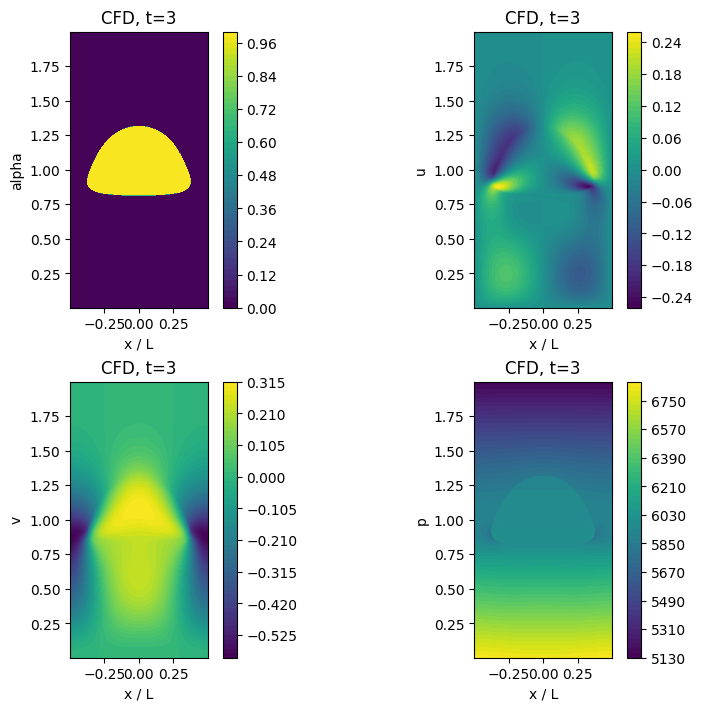

In [7]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

# Укажи путь до нужного .h5 файла и номер временного слоя.
h5_path = Path("cfd_data/rising_bubble_basilisk_r030.h5")
time_layer = -1  # можно использовать отрицательные индексы, например -1
spatial_step = 1  # увеличь, если файл большой и отрисовка тормозит

if not h5_path.is_absolute():
    base_dir = PROJECT_DIR if "PROJECT_DIR" in globals() else Path.cwd()
    h5_path = base_dir / h5_path

with h5py.File(h5_path, "r") as h5:
    required = ("velocityX", "velocityY", "pressure")
    missing = [name for name in required if name not in h5]
    if missing:
        raise KeyError(f"В файле нет датасетов: {missing}. Доступные ключи: {list(h5.keys())}")

    n_times = h5["pressure"].shape[0]
    t_idx = time_layer if time_layer >= 0 else n_times + time_layer
    if not 0 <= t_idx < n_times:
        raise IndexError(f"time_layer={time_layer} вне диапазона [{-n_times}, {n_times - 1}]")

    step = max(1, int(spatial_step))
    ux = h5["velocityX"][t_idx, ::step, ::step].T
    uy = h5["velocityY"][t_idx, ::step, ::step].T
    pressure = h5["pressure"][t_idx, ::step, ::step].T
    alpha = (h5["levelset"][t_idx, ::step, ::step].T < 0.0).astype(float) if "levelset" in h5 else None
    time_value = h5["time"][t_idx] if "time" in h5 else None

    x_key = "X" if "X" in h5 else "x"
    y_key = "Y" if "Y" in h5 else "y"
    x = h5[x_key][::step] if x_key in h5 else np.arange(pressure.shape[1])
    y = h5[y_key][::step] if y_key in h5 else np.arange(pressure.shape[0])

l_ref = cfg.physics.l_ref if "cfg" in globals() else 1.0
x = x / l_ref
y = y / l_ref

plots = []
if alpha is not None:
    plots.append((alpha, "alpha"))
plots.extend([(ux, "u"), (uy, "v"), (pressure, "p")])

fig, axes = plt.subplots(2, 2, figsize=(8, 7), constrained_layout=True)
axes = axes.ravel()
title_time = float(time_value) if time_value is not None else t_idx

for ax, (field, ylabel) in zip(axes, plots):
    im = ax.contourf(x, y, field, levels=60, cmap="viridis")
    ax.set_title(f"CFD, t={title_time:.4g}")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("x / L")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax)

for ax in axes[len(plots):]:
    ax.axis("off")

label = f"{h5_path} | layer {time_layer} -> {t_idx}"
if time_value is not None:
    label += f" | t = {float(time_value):.6g}"
print(label)
plt.show()
